In [ ]:
from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))

In [92]:
#use the Q2 2016 data first
import sys
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import datetime
import pandas as pd
import seaborn
import random

import torch
import torchvision
import torchvision.transforms as transforms
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
def find_nearest_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return(idx)

In [94]:
#ercot 2017 loads

path = "./../data/ercot/"
ercot2017 = pd.read_excel(path + "native_Load_2017.xlsx")

testloads = np.array(list(ercot2017['ERCOT']))

In [95]:
startdate = datetime.datetime(year=2010, month=1, day=1, hour=0, minute=0, second=0)
curr = startdate
enddate = datetime.datetime(year=2018, month=1, day=1, hour=0, minute=0, second=0)

allhours = []

while curr < enddate:
    allhours.append(curr)
    curr += datetime.timedelta(hours=1)
    
trainhours = np.array(allhours[0:-8760]) #all but last year, not a leap year
testhours = np.array(allhours[-8760:])

#get indecies of day starts in testhours
startdate = datetime.datetime(year=2017, month=1, day=1, hour=0, minute=0, second=0)
curr = startdate
enddate = datetime.datetime(year=2018, month=1, day=1, hour=0, minute=0, second=0)

day_start_i = []
i = 0

while curr < enddate:
    if curr.hour == 0:
        day_start_i.append(i)
    curr += datetime.timedelta(hours=1)
    i += 1


In [96]:
#ERCOT data
lds = datetime.datetime(year=2016, month=2, day=29, hour=0, minute=0) #lines 1415 to 1439
lde = datetime.datetime(year=2016, month=2, day=29, hour=23, minute=0)

path = "./../data/ercot/"
ercot2017 = pd.read_excel(path + "native_Load_2017.xlsx")
ercot2016 = pd.read_excel(path + "native_Load_2016.xlsx") #leap year
ercot2016.drop(ercot2016.index[1415:1439], inplace=True) #dropping leap days so years line up

ercot2015 = pd.read_excel(path + "native_Load_2015.xls")
ercot2014 = pd.read_excel(path + "2014_ERCOT_Hourly_Load_Data.xls")
ercot2013 = pd.read_excel(path + "2013_ERCOT_Hourly_Load_Data.xls")
ercot2012 = pd.read_excel(path + "2012_ERCOT_Hourly_Load_Data.xls") #leap year
ercot2012.drop(ercot2012.index[1415:1439], inplace=True)

ercot2011 = pd.read_excel(path + "2011_ERCOT_Hourly_Load_Data.xls")
ercot2010 = pd.read_excel(path + "2010_ERCOT_Hourly_Load_Data.xls")

yearly_data = [ercot2010, ercot2011, ercot2012, ercot2013, ercot2014, ercot2015, ercot2016, ercot2017]
training = [list(ercot2010['ERCOT']), list(ercot2011['ERCOT']), list(ercot2012['ERCOT']), list(ercot2013['ERCOT']), list(ercot2014['ERCOT']), list(ercot2015['ERCOT']), list(ercot2016['ERCOT'])]
means = [ np.nanmean(y) for y in training ]

A = np.vstack((np.array([0, 1, 2, 3, 4, 5, 6]), np.array([1, 1, 1, 1, 1, 1, 1]))).T

## Subsituting the code: a, b = np.linalg.lstsq(A, np.array(means))[0] since it crashes the kernel
# use system-wide loadgrowth for all regions
# Solve the least-squares problem manually using the normal equation
ATA = np.dot(A.T, A)  # Compute A^T A
ATb = np.dot(A.T, np.array(means))  # Compute A^T b
solution = np.dot(np.linalg.inv(ATA), ATb)  # Compute (A^T A)^(-1) A^T b

# Extract a and b from the solution
a, b = solution[0], solution[1]


In [97]:
print(a, b)
projected_mean = a*7.0 + b

570.2781314827629 36556.579009511486


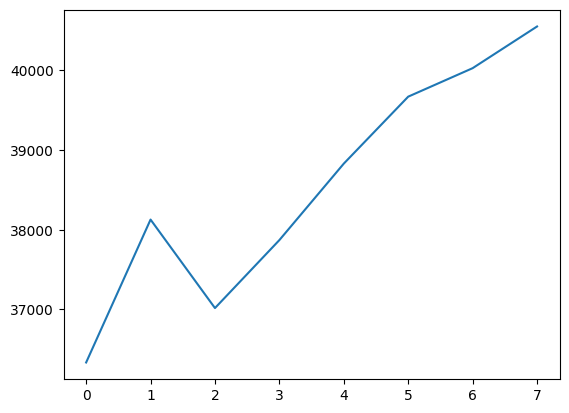

In [98]:
plt.plot(means + [projected_mean])
plt.show()

In [ ]:


means.append(projected_mean)
load_growth = np.array(means)

yearly_loads = np.zeros((8,8760))

for i in range(len(yearly_data)):
    yearly_loads[i,:] = np.array(yearly_data[i]['ERCOT']) - load_growth[i]
    
    
#need to calculate cdf per month    
model = np.nanmean(yearly_loads[0:6,:], axis=0)
test = yearly_loads[7,:]
#plt.plot(model, color="blue", label="model")
#plt.plot(test, color="red", label="test data")
#plt.legend()
#plt.show()

Yearly loads are described as the the ercot data minus the means to account for the moving growth. This will normalise the data so we can focus on the actual peaks and worry less of the moving average. Will stabilise and remove the seasonality effects.

In [100]:
model

array([-6272.28308438, -6664.14711221, -7047.33485354, ...,
       -2660.01225671, -3996.54575688, -5064.35739987], shape=(8760,))

In [101]:
np.nanmax(yearly_loads[0:10,:])

np.float64(31066.880542458108)

In [102]:
dayspermonth = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

for j in range(len(dayspermonth)):
    hstart = 0 
    for k in range(j):
        hstart += dayspermonth[k]*24
    hend = hstart + dayspermonth[j]*24
    
    print(hstart, hend)

#dayspermonth = [31, 28, 31, 30, 31, 30, 31, 30, 31, 30, 31]

0 744
744 1416
1416 2160
2160 2880
2880 3624
3624 4344
4344 5088
5088 5832
5832 6552
6552 7296
7296 8016
8016 8760


In [103]:
def find_nearest_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return(idx)

In [104]:
dayspermonth[1]*24

672

In [113]:
power_vals = np.arange(np.min(model),np.max(model),0.5)
monthly_power_vals = {}
true_power_vals = {}
monthly_average_power_vals = {}
true_cdf = {}
empirical_cdf = {}
avg_model_ranks = []#np.zeros((yearly_loads.shape[1], 1))
emp_model_ranks = []
test_ranks = []#np.zeros((yearly_loads.shape[1], 1))

true_monthly_max = {}
true_monthly_min = {}
model_monthly_max = {}
model_monthly_min = {}

#for each month
for j in range(len(dayspermonth)):
    true_cdf[j] = []  # list to store true CDF values for each month
    empirical_cdf[j] = []  # list to store empirical CDF values for each month
    hstart = 0 

    #calculate the number of hours in each month till jth month (j is 0 indexed)
    for k in range(j):
        hstart += dayspermonth[k]*24
    hend = hstart + dayspermonth[j]*24
    
    ## Note that we are now only testing the month we are intrested in, not the entire year with hstart and hend
    
    #support over expected monthly maxes and mins
    monthly_average_power_vals[j] = np.arange(np.min(model[hstart:hend,]),np.max(model[hstart:hend,]),0.5)
    
    #support over empirical monthly maxes and mins
    model_monthly_max[j] = np.nanmax(yearly_loads[0:6,hstart:hend])
    model_monthly_min[j] = np.nanmin(yearly_loads[0:6,hstart:hend])
    
    true_monthly_max[j] = np.nanmax(test[hstart:hend,])
    true_monthly_min[j] = np.nanmin(test[hstart:hend,])
    
    monthly_power_vals[j] = np.arange(model_monthly_min[j],model_monthly_max[j],0.5)
    true_power_vals[j] = np.arange(true_monthly_min[j],true_monthly_max[j],0.5)

    
    ##calculate monthly empirical cdf based on hourly average model

    for p in monthly_power_vals[j]:
        greater = np.sum([ 1 for k in model[hstart:hend,] if k >= p ])/float(dayspermonth[j]*24)
        empirical_cdf[j].append(1.0 - greater)
    
    ##calculate true cdf values for each hour of 2017
    # for each power value in the monthly power values,
    # calculate the average hourly proportion of test data that is greater than or equal to that power value
    for p in monthly_power_vals[j]:
        greater = np.sum([ 1 for k in test[hstart:hend,] if k >= p ])/float(dayspermonth[j]*24)
        true_cdf[j].append(1.0 - greater)
    
    ## processes hourly load data for each month, calculates cumulative distribution functions (CDFs), 
    # and ranks the test data against the model and empirical distributions.
    # iterates over hours in the month, calculates the CDF for each hour, and ranks the test data against the model and empirical distributions.
    for i in range(hstart,hend):
        val = test[i,]                                                           # extract test values for the current hour
        idx_avg = find_nearest_idx(monthly_average_power_vals[j], val)           # find the index of the nearest value in the monthly average power values
        mod_avg = empirical_cdf[j][idx_avg]                                      # get the corresponding empirical CDF value for the model
        avg_model_ranks.append(mod_avg)                                          # append the empirical CDF value to the avg_model_ranks list
        
        idx_emp = find_nearest_idx(monthly_power_vals[j], val)                   # find the index of the nearest value in the monthly power values
        mod = empirical_cdf[j][idx_emp]                                          # get the corresponding empirical CDF value for the empirical distribution
        emp_model_ranks.append(mod)                                              # append the empirical CDF value to the emp_model_ranks list
        
        idx_true = find_nearest_idx(true_power_vals[j], val)                     # find the index of the nearest value in the true monthly power values
        if idx_true > len(true_cdf[j]) - 1:                                             # check if the index is out of bounds
            idx_true = len(true_cdf[j]) - 1                                        # if so, set it to the last index
        true = true_cdf[j][idx_true]                                           # else get the corresponding true CDF value for the test data
        test_ranks.append(true)                                                # append the true CDF value to the test_ranks list
    


Things I have changed...

for i in range(hstart,hend + 1)     -> for i in range(hstart,hend)

dayspermonth = [31, 28, 31, 30, 31, 30, 31, 30, 31, 30, 31]      ->       dayspermonth = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

    by commenting out... 

The cumulative distribution function (CDF) values for a particular hour represent the proportion of power load values that are less than or equal to a given power value within the specified range. For the model's CDF (`empirical_cdf`), this is calculated based on the predicted power values for that hour, while for the true CDF (`true_cdf`), it is based on the actual test data for that hour.

In essence, the CDF value at a specific power level indicates the likelihood (or cumulative probability) that the power load will not exceed that level during the hour in question. This allows for a comparison between the model's predictions and the actual observed data, helping to evaluate how well the model captures the distribution of power loads.

Notice how the true_power_vals (orange line) has a larger bias and more observations. The true cdf only captures the range in the monthly_power_vals (green line)

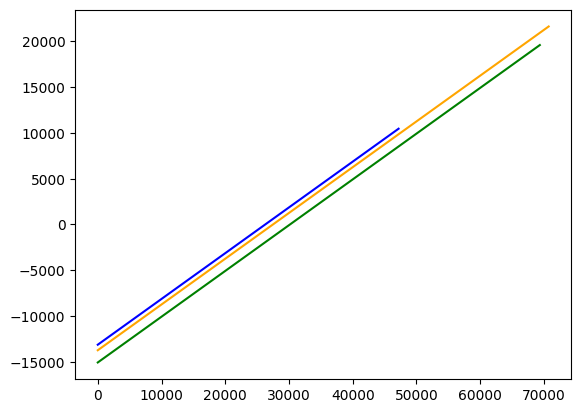

In [114]:
plt.plot(monthly_power_vals[9], color="green", label="power values")
plt.plot(true_power_vals[9], color="orange", label="true power values")
plt.plot(monthly_average_power_vals[9], color="blue", label="monthly average power values")
plt.show()

In essence the purpose of making the cdf from the power values of the training set is to seperate the train and test. If the testing values are beyond the training set then we can take the largest value from the training power (last index) and obtain the cdf from that. From what we can observe that of the last index is of 1 suggesting that the probability of exceeding this value is likely

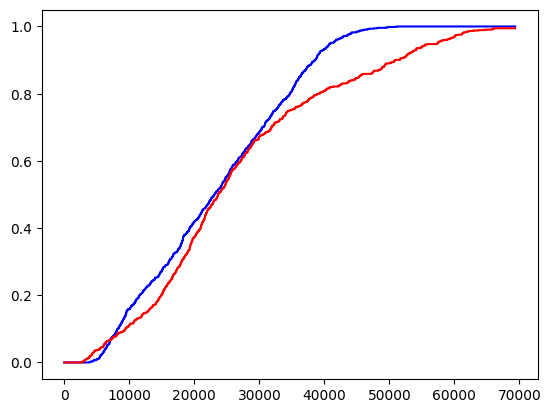

In [115]:
plt.plot(empirical_cdf[9], color="blue", label="empirical model")
plt.plot(true_cdf[9], color="red", label="true data")
plt.show()

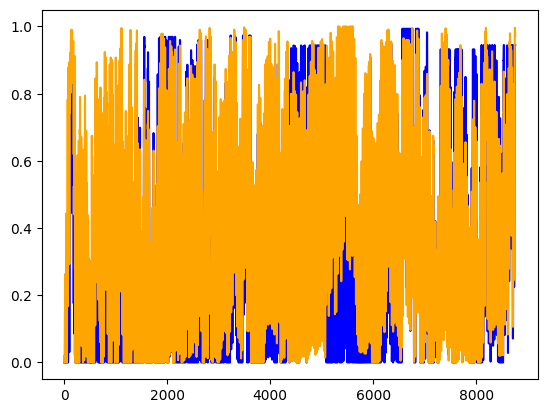

In [116]:
plt.plot(avg_model_ranks, color="blue")
plt.plot(test_ranks, color="orange")
plt.show()

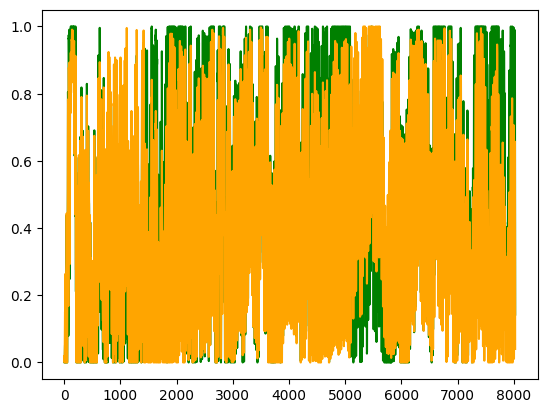

In [78]:
plt.plot(emp_model_ranks, color="green")
plt.plot(test_ranks, color="orange")
plt.show()

In [117]:
for i in range(len(dayspermonth)):
    print(i,": Minimum:", np.min(monthly_power_vals[i]), "|   Maximum:",np.max(monthly_power_vals[i]))

0 : Minimum: -15546.159283072608 |   Maximum: 19369.840716927392
1 : Minimum: -15444.111143072609 |   Maximum: 19156.38885692739
2 : Minimum: -15554.009898072592 |   Maximum: 15898.490101927408
3 : Minimum: -15760.955786072613 |   Maximum: 12601.044213927387
4 : Minimum: -15177.863321072608 |   Maximum: 21938.636678927392
5 : Minimum: -12141.481470029354 |   Maximum: 29540.518529970646
6 : Minimum: -8421.716544122839 |   Maximum: 28800.28345587716
7 : Minimum: -8333.099679229803 |   Maximum: 30190.400320770197
8 : Minimum: -13107.605660583897 |   Maximum: 27859.894339416103
9 : Minimum: -15074.877579072603 |   Maximum: 19602.122420927397
10 : Minimum: -15052.68775607261 |   Maximum: 11988.31224392739
11 : Minimum: -13628.369690072603 |   Maximum: 15801.130309927397


In [118]:
for i in range(len(dayspermonth)):
    print(i,": Minimum:", np.min(true_power_vals[i]), "|   Maximum:",np.max(true_power_vals[i]))

0 : Minimum: -13715.967053390828 |   Maximum: 19087.53294660917
1 : Minimum: -14461.258570190828 |   Maximum: 2179.2414298091717
2 : Minimum: -13641.179195390829 |   Maximum: 6545.320804609171
3 : Minimum: -14982.400359690826 |   Maximum: 12871.599640309174
4 : Minimum: -14644.851532190827 |   Maximum: 18695.148467809173
5 : Minimum: -9535.486515890829 |   Maximum: 27068.51348410917
6 : Minimum: -6005.987971890827 |   Maximum: 28947.512028109173
7 : Minimum: -10935.197528890829 |   Maximum: 27324.30247110917
8 : Minimum: -11649.913403890827 |   Maximum: 23085.086596109173
9 : Minimum: -13739.699511890827 |   Maximum: 21631.800488109173
10 : Minimum: -13325.482450890828 |   Maximum: 10070.017549109172
11 : Minimum: -12886.475510890828 |   Maximum: 13875.524489109172


In [ ]:
#compare perfect load forecast
#using neural network
#perfect and no action bars
#cdf or load forecasting
#time budget for load shedding